In [9]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
import scipy.optimize as scippy
import scipy.stats as scist
from numpy.fft import fft, ifft
import os
import shutil
from numba import njit, prange
from scipy.integrate import quad

plt.rc("xtick", labelsize=20, top=True, direction="in")
plt.rc("ytick", labelsize=20, right=True, direction="in")
plt.rc("axes", titlesize=26)
plt.rc("axes", labelsize=26)
plt.rc("legend", fontsize=26)

In [10]:
# Simulation parameters
N = 50

sigma = 1.0
L = 10.0*sigma
rho = N/(L**2) # 2D

kappa = 1.0
r_cut = 6.0 / kappa

gamma = 1.0 # gamma=xi from previously

kBT = 1.0
V_0 = 1.0
U_0 = V_0 / kBT

F_D = 1.0 * kBT / sigma

tau = gamma * sigma**2 / V_0 # Time unit for everything
dt = 1e-4 * tau
t_equil = 10.0 * tau
t_prod = 10.0 * tau
# t_sim = t_equil + t_prod

n_steps_equil = int(t_equil / dt)
n_steps_prod = int(t_prod / dt)

N_save = 10

In [ ]:
# Minimum image convention
@njit(fastmath=True)
def min_image(dx, L):
    return dx - L * np.round(dx / L)

# Might want to smoothe the cutoff later
@njit(fastmath=True)
def V_Yuk(r):
    if 0 < r < r_cut:
        return V_0*sigma/r * np.exp( -kappa*(r-sigma) )
    elif r >= r_cut:
        return 0.0
    else:
        raise ValueError

# Quotient rule derivative; double-check at some point
@njit(fastmath=True)
def F_Yuk(r):
    if 0 < r < r_cut:
        return V_0*sigma * np.exp( -kappa*(r-sigma) ) * (kappa*r + 1) / r**2
    elif r >= r_cut:
        return 0.0
    else:
        raise ValueError

# Intialize particles on a 2D grid, deleting some randomly if N isn't a square number
def init_grid(L, N):
    # Find smallest integer grid size n such that n^2 >= N
    n = int(np.ceil(np.sqrt(N)))

    # Build n×n grid
    coords = np.linspace(0.5*sigma, L - 0.5*sigma, n)
    X, Y= np.meshgrid(coords, coords, indexing='ij')
    pts = np.column_stack([X.ravel(), Y.ravel()])

    # Randomly choose exactly N points, implicitly deleting the rest by replace=False
    idx = np.random.choice(len(pts), N, replace=False)
    return pts[idx]

# Compute the forces using the Yukawa interaction
@njit(fastmath=True)
def compute_forces(pos):
    forces = np.zeros((N, 2))

    for i in range(N):
        xi, yi = pos[i]

        for j in range(i + 1, N): # <-- Only compute j > i to utilize the symmetry
            dx = min_image(xi - pos[j, 0], L)
            dy = min_image(yi - pos[j, 1], L)
            r = np.sqrt(dx*dx + dy*dy)

            F_mag = F_Yuk(r) # Magnitude of the force

            fx = F_mag * dx / r
            fy = F_mag * dy / r

            # Apply Newton's third law / symmetry of the force matrix:
            forces[i, 0] += fx
            forces[i, 1] += fy

            forces[j, 0] -= fx
            forces[j, 1] -= fy
            
    return forces

# Brownian Dynamics integration step with only the Yukawa force
@njit(fastmath=True)
def bd_step_equil(pos):
    F_matrix = compute_forces(pos)
    noise = np.sqrt(2 * kBT * dt / gamma) * np.random.normal(0.0, 1.0, (N, 2)) # Add thermal noise
    pos = pos + dt * F_matrix / gamma + noise # Update positions with forces and noise

    return pos

# Brownian Dynamics integration step with species-based external driving
@njit(fastmath=True)
def bd_step_drive(pos, species):
    F_matrix = compute_forces(pos)
    F_matrix[:,0] += species * F_D # # external driving force

    noise = np.sqrt(2 * kBT * dt / gamma) * np.random.normal(0.0, 1.0, (N, 2)) # Add thermal noise
    pos = pos + dt * F_matrix / gamma + noise # Update positions with forces and noise

    return pos

# g(r) computation
@njit
def compute_gr(pos, r_max, dr):
    n_bins = int(r_max / dr)
    hist = np.zeros(n_bins)

    for i in range(N):
        xi, yi = pos[i]
        for j in range(i+1, N):
            dx = min_image(xi - pos[j,0], L)
            dy = min_image(yi - pos[j,1], L)
            r = np.sqrt(dx*dx + dy*dy)

            if r < r_max:
                bin_idx = int(r / dr)
                hist[bin_idx] += 2.0

    return hist

#MSD computation
@njit(fastmath=True)
def compute_msd(pos, pos0):
    msd = 0.0

    for i in range(N):
        dx = pos[i, 0] - pos0[i, 0]
        dy = pos[i, 1] - pos0[i, 1]

        # minimum image convention
        # dx -= L * np.round(dx / L)
        # dy -= L * np.round(dy / L)

        msd += dx*dx + dy*dy

    return msd / N

In [12]:
pos = init_grid(L, N)

# Equilibration
for step in range(n_steps_equil):
    pos = bd_step_equil(pos)

pos0 = pos.copy() # Want the initial position to be after equilibration

# Plot positions, potentially w/o the equilibration above to check that everything works:
# fig, ax = plt.subplots(figsize=(5, 5))

# ax.scatter(pos[:, 0], pos[:, 1])
# ax.set_aspect('equal')
# fig.tight_layout()

In [13]:
# Main simulation
print("Running Brownian Dynamics simulation...")
# V_0 = 0.0
# F_D = 0.0 * kBT / sigma

# Species labels f_i = ±1
species = np.ones(N)
species[:N // 2] = -1
np.random.shuffle(species)

# g(r)
r_max = L / 2
dr = 0.05 * sigma
n_bins = int(r_max / dr)
g_hist = np.zeros(n_bins)
n_samples = 0


ts, MSDs = [0.0], [compute_msd(pos, pos0)]
for step in range(n_steps_prod):
        pos = bd_step_drive(pos, species)

        if step % (n_steps_prod // N_save) == 0:
                ts.append(step * dt)
                MSDs.append(compute_msd(pos, pos0))
                print(f"Progress: {100 * step / n_steps_prod:.0f}%")

        if step % 100 == 0:
                g_hist += compute_gr(pos, r_max, dr)
                n_samples += 1

print("Simulation finished.")

# Normalize g(r)
r = (np.arange(n_bins) + 0.5) * dr
area = 2 * np.pi * r * dr
norm = n_samples * N * rho * area
g_r = g_hist / norm


pos_L, pos_R = [], []
for position, flag in zip(pos, species):
        if flag == 1:
                pos_R.append(position)
        elif flag == -1:
                pos_L.append(position)
        else:
                raise ValueError
pos_L = np.array(pos_L)
pos_R = np.array(pos_R)

Running Brownian Dynamics simulation...
Progress: 0%
Progress: 10%
Progress: 20%
Progress: 30%
Progress: 40%
Progress: 50%
Progress: 60%
Progress: 70%
Progress: 80%
Progress: 90%
Simulation finished.


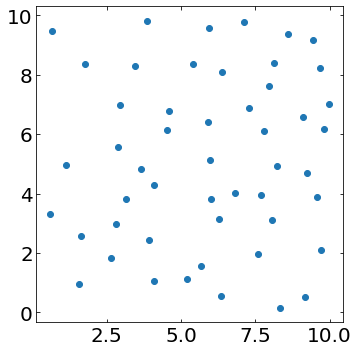

In [20]:
fig, ax = plt.subplots(figsize=(5, 5))

pos_image = pos.copy()
for i in range(N):
        pos_image[i,0] -= L * np.floor(pos_image[i,0] / L) # Apply periodic boundary conditions
        pos_image[i,1] -= L * np.floor(pos_image[i,1] / L)

ax.scatter(pos_image[:, 0], pos_image[:, 1])
# ax.scatter(pos_L[:, 0], pos_L[:, 1])
ax.set_aspect('equal')
fig.tight_layout()

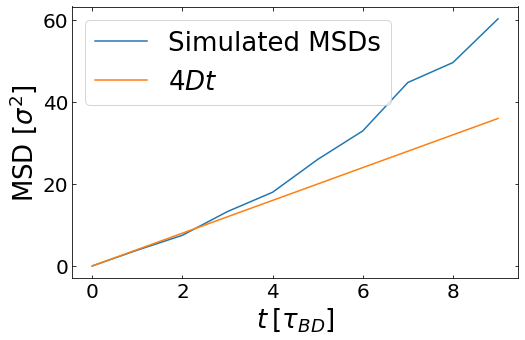

In [15]:
# Plot MSDs

plt.figure(figsize=(8, 5))

plt.plot(ts, MSDs, label=r'Simulated MSDs')
plt.plot(ts, 4*np.array(ts), label=r'$4Dt$')

plt.xlabel(r"$t\:[\tau_{BD}]$")
plt.ylabel(r"MSD [$\sigma^2 $]") # $\langle |\vec{r}(t) - \vec{r}(0)|^2 \rangle$

plt.legend()

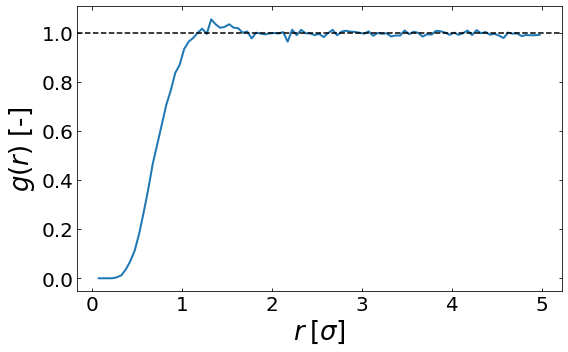

In [16]:
# Plot g(r)
plt.figure(figsize=(8, 5))
plt.plot(r[1:], g_r[1:], lw=2)
plt.axhline(1.0, color="k", ls="--")

plt.xlabel(r"$r\:[\sigma]$")
plt.ylabel(r"$g(r)$ [-]")

plt.tight_layout()
plt.show()